In [1]:
import pandas as pd

df=pd.read_csv("Housing.csv")

In [2]:
df.shape

(545, 13)

In [3]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

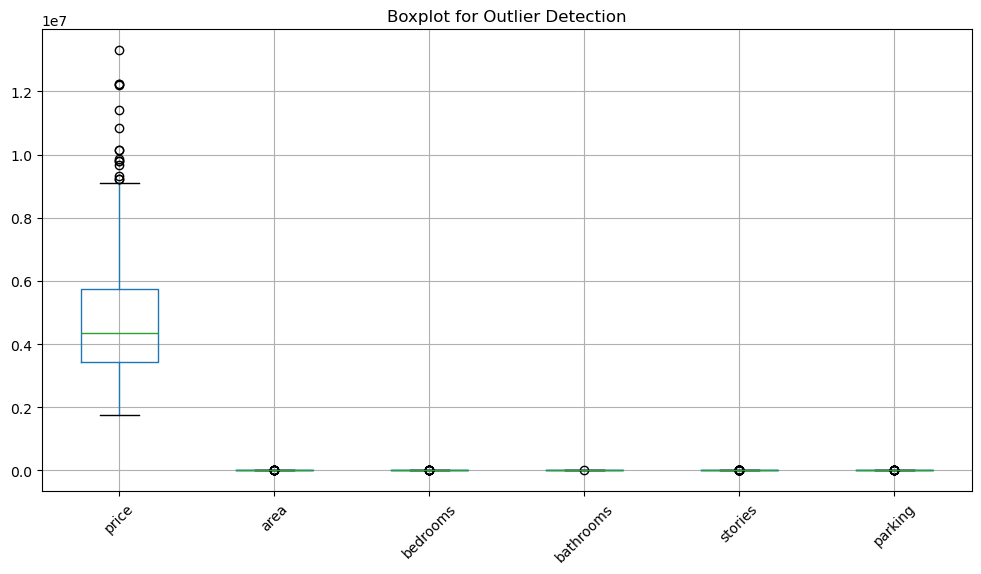

In [7]:
import matplotlib.pyplot as plt
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,6))
numeric_df.boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [8]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


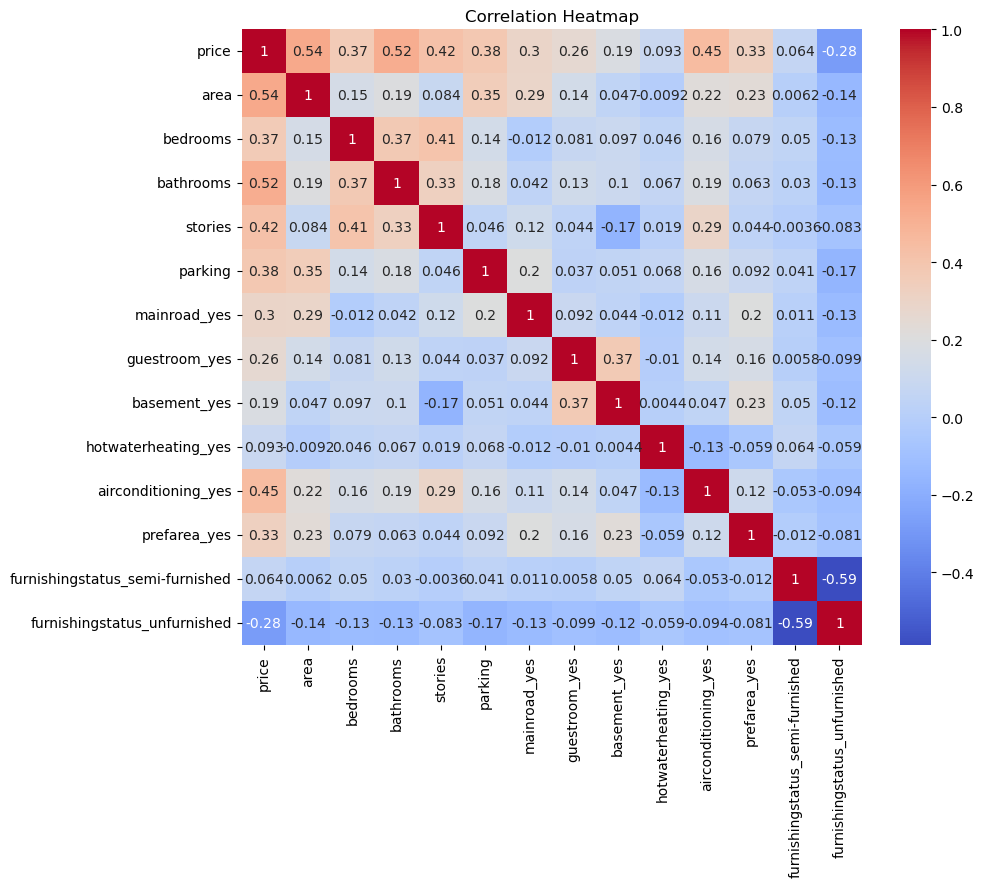

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394,0.296898,0.255517,0.187057,0.093073,0.452954,0.329777,0.063656,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980,0.288874,0.140297,0.047417,-0.009229,0.222393,0.234779,0.006156,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270,-0.012033,0.080549,0.097312,0.046049,0.160603,0.079023,0.050040,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496,0.042398,0.126469,0.102106,0.067159,0.186915,0.063472,0.029834,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547,0.121706,0.043538,-0.172394,0.018847,0.293602,0.044425,-0.003648,-0.082972
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000,0.204433,0.037466,0.051497,0.067864,0.159173,0.091627,0.041327,-0.165705
mainroad_yes,0.296898,0.288874,-0.012033,0.042398,0.121706,0.204433,1.000000,0.092337,0.044002,-0.011781,0.105423,0.199876,0.011450,-0.133123
guestroom_yes,0.255517,0.140297,0.080549,0.126469,0.043538,0.037466,0.092337,1.000000,0.372066,-0.010308,0.138179,0.160897,0.005821,-0.099023
basement_yes,0.187057,0.047417,0.097312,0.102106,-0.172394,0.051497,0.044002,0.372066,1.000000,0.004385,0.047341,0.228083,0.050284,-0.117935
hotwaterheating_yes,0.093073,-0.009229,0.046049,0.067159,0.018847,0.067864,-0.011781,-0.010308,0.004385,1.000000,-0.130023,-0.059411,0.063819,-0.059194


In [9]:
import seaborn as sns
corr = df_encoded.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

corr

In [10]:
X=df_encoded.drop("price", axis=1).astype(float).to_numpy()
y=df_encoded["price"].astype(float).to_numpy().reshape(-1, 1)

indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

split=int(0.8*len(X))

X_train=X[:split]
X_test=X[split:]
y_train=y[:split]
y_test=y[split:]

In [11]:
mean=X_train.mean(axis=0)
std=X_train.std(axis=0)

std[std==0]=1

X_train=(X_train-mean)/std
X_test=(X_test-mean)/std

y_mean=y_train.mean()
y_std=y_train.std()

y_train=(y_train-y_mean)/y_std
y_test=(y_test-y_mean)/y_std

In [12]:
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n=X.shape
    theta=np.zeros((n, 1))
    costs=[]

    for i in range(epochs):
        predictions=X.dot(theta)
        errors=predictions-y
        
        gradient=X.T.dot(errors)/m
        theta-=lr*gradient
        
        cost=np.sum(errors**2)/(2*m)
        costs.append(cost)

    return theta, costs

theta, costs = gradient_descent(X_train, y_train, lr=0.01, epochs=2000)

theta[:5]

array([[0.30453931],
       [0.05280021],
       [0.27504273],
       [0.20285538],
       [0.11536804]])

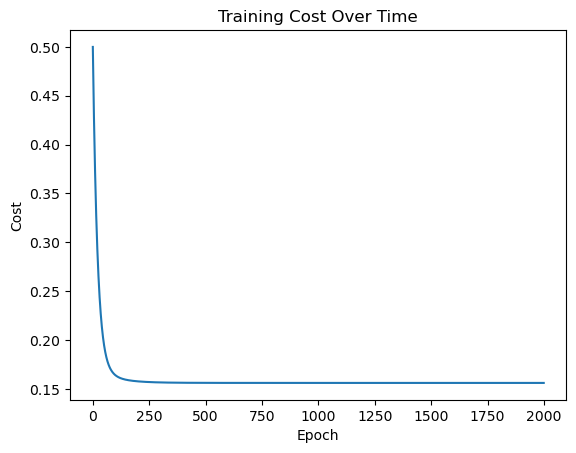

In [13]:
plt.plot(costs)
plt.title("Training Cost Over Time")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

In [14]:
y_pred = X_test.dot(theta)

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.6483198747535646
MSE: 0.3534476572254424


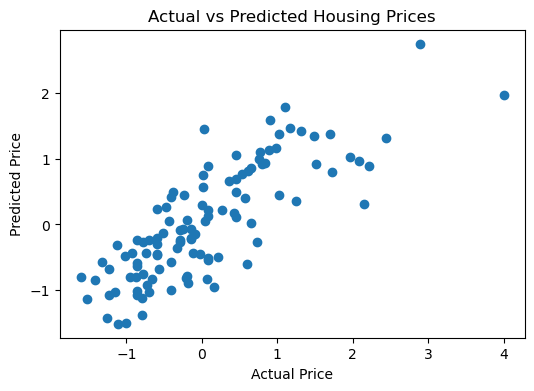

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

In [17]:
names=df_encoded.drop("price", axis=1).columns
coeffs=(y_std/std).reshape(-1, 1)*theta
intercept=y_mean-((y_std*(mean/std)).reshape(1, -1).dot(theta)).item()
terms=[]
for n, c in zip(names, coeffs.flatten()):
    terms.append(f"({c:.4f})*{n}")
equation=f"price = {intercept:.4f} + " + " + ".join(terms)
print(equation)
print('\nIntercept:', intercept)
print('First 10 coefficients:')
for n, c in list(zip(names, coeffs.flatten()))[:10]:
    print(f"  {n}: {c:.6f}")

price = -165137.8784 + (256.8693)*area + (135421.8150)*bedrooms + (1023086.2275)*bathrooms + (441554.0658)*stories + (250977.4195)*parking + (525617.3354)*mainroad_yes + (161179.4343)*guestroom_yes + (396008.5702)*basement_yes + (722340.5699)*hotwaterheating_yes + (866794.4477)*airconditioning_yes + (636007.6019)*prefarea_yes + (-79069.4543)*furnishingstatus_semi-furnished + (-402402.3181)*furnishingstatus_unfurnished

Intercept: -165137.87843190506
First 10 coefficients:
  area: 256.869296
  bedrooms: 135421.814973
  bathrooms: 1023086.227490
  stories: 441554.065832
  parking: 250977.419478
  mainroad_yes: 525617.335355
  guestroom_yes: 161179.434328
  basement_yes: 396008.570178
  hotwaterheating_yes: 722340.569878
  airconditioning_yes: 866794.447688
